<a href="https://colab.research.google.com/github/xavierjacomep/curso-intro-machine-learning/blob/main/01_regresion_lineal_simple.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div style="background:#0F172A; padding:36px 48px;">
  <h1 style="color:#FFFFFF; font-size:2em; margin:0; font-weight:800; letter-spacing:1px;">
    🏠 MI PRIMER REGRESOR EN MACHINE LEARNING
  </h1>
  <h2 style="color:#38BDF8; font-size:1.1em; margin:12px 0 6px 0; font-weight:400;">
    Caso Práctico: Valoración de Bienes Raíces (Sindian Dist., New Taipei City, Taiwán)
  </h2>
  <p style="color:#94A3B8; margin:0; font-size:0.95em;">
    Notebook 1 de 3 — Nivel: BÁSICO · Pipeline de Regresión Lineal + Validación de Supuestos
  </p>
</div>

---
## 🎯 Objetivo de este notebook

Construir nuestro primer modelo de regresión, siguiendo la misma lógica de pipeline que usamos
en los talleres de clasificación (carga → limpieza → separación de datos → escalamiento →
entrenamiento → evaluación), y **además**, porque el algoritmo usado es un modelo
**paramétrico** (Regresión Lineal), vamos a **validar formalmente sus 5 supuestos clásicos**.
Si algún supuesto no se cumple, aplicaremos el ajuste correspondiente y volveremos a evaluar.

**Dataset:** [Real Estate Valuation Data Set — UCI ML Repository](https://archive.ics.uci.edu/dataset/477/real+estate+valuation+data+set)
414 transacciones inmobiliarias en Taiwán. Predecimos `Y house price of unit area`
(precio de la vivienda por unidad de área, en 10,000 NT$/Ping) a partir de 6 variables.

**Algoritmo:** Regresión Lineal Múltiple.

### ¿Por qué validar supuestos solo en este modelo, y no en Random Forest o Gradient Boosting?

Los modelos basados en árboles (que veremos en los Notebooks 2 y 3) son **no paramétricos**:
no asumen una forma funcional específica para la relación entre las variables y el precio, por
lo que no requieren validar linealidad, normalidad de residuos, homocedasticidad, etc.
La Regresión Lineal, en cambio, **sí** hace esos supuestos explícitamente — y si no se
cumplen, tanto las predicciones como la interpretación de los coeficientes (y cualquier prueba
de hipótesis sobre ellos) pueden ser poco confiables.

---
## 📦 Paso 0 — Importar librerías

In [1]:
# Manejo de datos
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocesamiento
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Modelo
from sklearn.linear_model import LinearRegression

# Métricas de regresión
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
    r2_score
)

# Validación de supuestos de la Regresión Lineal
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan, linear_rainbow
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy import stats

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
RANDOM_STATE = 42

print("✅ Librerías importadas")

✅ Librerías importadas


---
## 📂 Paso 1 — Cargar los datos

Usamos el paquete oficial `ucimlrepo`, recomendado por el propio repositorio UCI, para
descargar el dataset directamente en un DataFrame de pandas.

In [2]:
!pip install -q ucimlrepo
from ucimlrepo import fetch_ucirepo

real_estate = fetch_ucirepo(id=477)
X_raw = real_estate.data.features
y_raw = real_estate.data.targets

df = pd.concat([X_raw, y_raw], axis=1)

print(f"Filas: {df.shape[0]}  |  Columnas: {df.shape[1]}")
df.head()

Filas: 414  |  Columnas: 7


,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
0,2012.917,32.0,84.87882,10,24.98298,121.54024,37.9
1,2012.917,19.5,306.59470,9,24.98034,121.53951,42.2
2,2013.583,13.3,561.98450,5,24.98746,121.54391,47.3
3,2013.500,13.3,561.98450,5,24.98746,121.54391,54.8
4,2012.833,5.0,390.56840,5,24.97937,121.54245,43.1


In [3]:
print("Columna                                    Tipo         Nulos")
print("-" * 65)
for col in df.columns:
    nulos = df[col].isnull().sum()
    print(f"  {col:<42} {str(df[col].dtype):<10}  {nulos}")

Columna                                    Tipo         Nulos
-----------------------------------------------------------------
  X1 transaction date                        float64     0
  X2 house age                               float64     0
  X3 distance to the nearest MRT station     float64     0
  X4 number of convenience stores            int64       0
  X5 latitude                                float64     0
  X6 longitude                               float64     0
  Y house price of unit area                 float64     0


---
## 📊 Paso 2 — EDA rápido: distribución y asimetría de cada variable

Antes de modelar, revisamos la **asimetría (skewness)** de cada variable. Esto nos da una
primera pista de posibles problemas de linealidad/normalidad más adelante: variables muy
asimétricas suelen tener relaciones no lineales con el target y generar residuos no normales.

In [4]:
FEATURES = [
    'X1 transaction date', 'X2 house age', 'X3 distance to the nearest MRT station',
    'X4 number of convenience stores', 'X5 latitude', 'X6 longitude'
]
TARGET = 'Y house price of unit area'

asimetria = df[FEATURES + [TARGET]].skew().sort_values(key=abs, ascending=False)
print("Asimetría (skewness) de cada variable:")
print(asimetria.round(3))
print()
print("Regla práctica: |skew| > 1 → asimetría fuerte, candidata a transformación")

Asimetría (skewness) de cada variable:
X3 distance to the nearest MRT station    1.889
X6 longitude                             -1.220
Y house price of unit area                0.600
X5 latitude                              -0.439
X2 house age                              0.383
X4 number of convenience stores           0.155
X1 transaction date                      -0.151
dtype: float64

Regla práctica: |skew| > 1 → asimetría fuerte, candidata a transformación


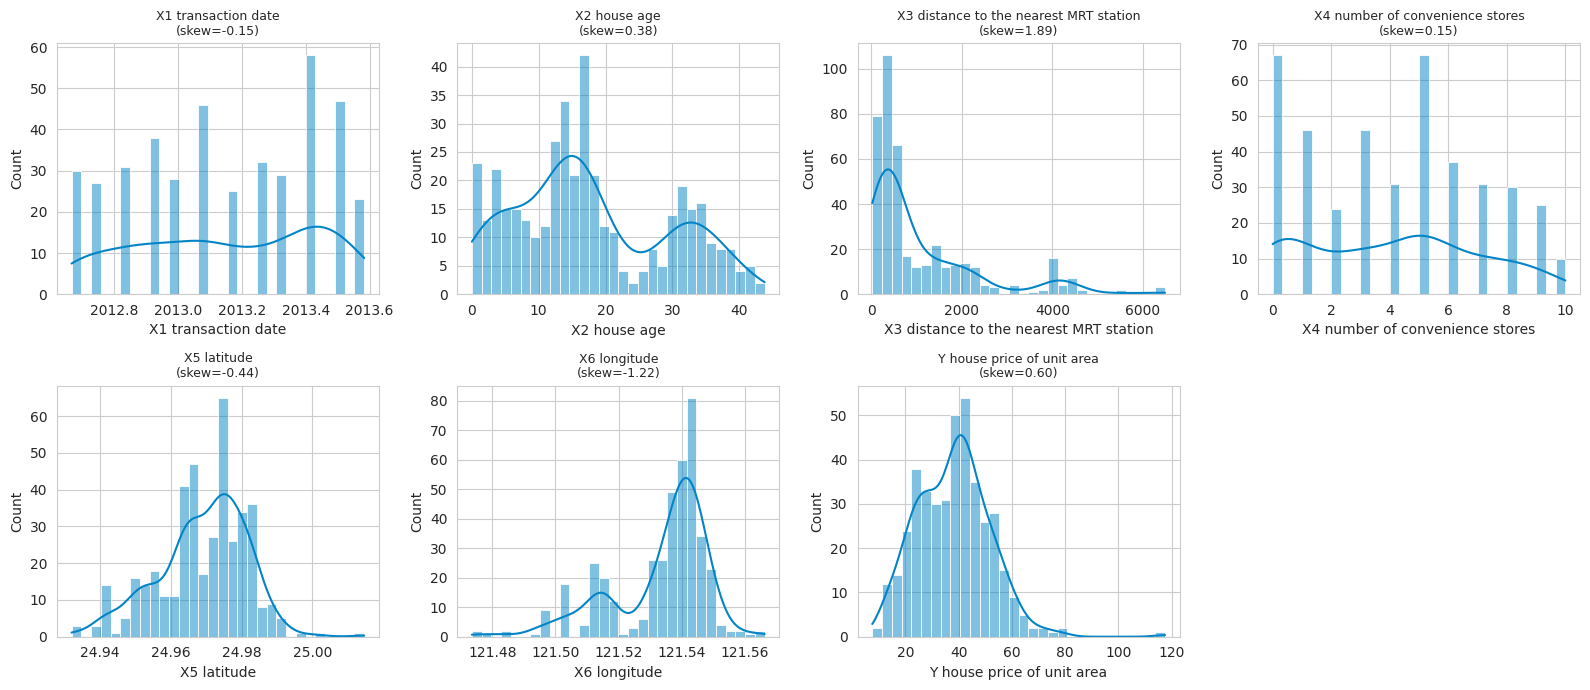

In [5]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()
for i, col in enumerate(FEATURES + [TARGET]):
    sns.histplot(df[col], bins=30, color='#0284C7', kde=True, ax=axes[i])
    axes[i].set_title(f'{col}\n(skew={df[col].skew():.2f})', fontsize=9)
axes[-1].axis('off')
plt.tight_layout()
plt.show()

> **Hallazgo clave:** `X3 distance to the nearest MRT station` tiene una asimetría muy fuerte
> (**skew ≈ 1.89**): la mayoría de viviendas están relativamente cerca del metro, pero unas
> pocas están extremadamente lejos. Guardamos esta observación — la retomaremos en el
> **Paso 12**, cuando ajustemos el modelo ante violaciones de supuestos.

---
## 🧹 Paso 3 — Limpieza mínima y correlaciones

Este dataset no tiene valores nulos (confirmado en el Paso 1). Verificamos duplicados y
revisamos la correlación entre variables.

Filas duplicadas: 0


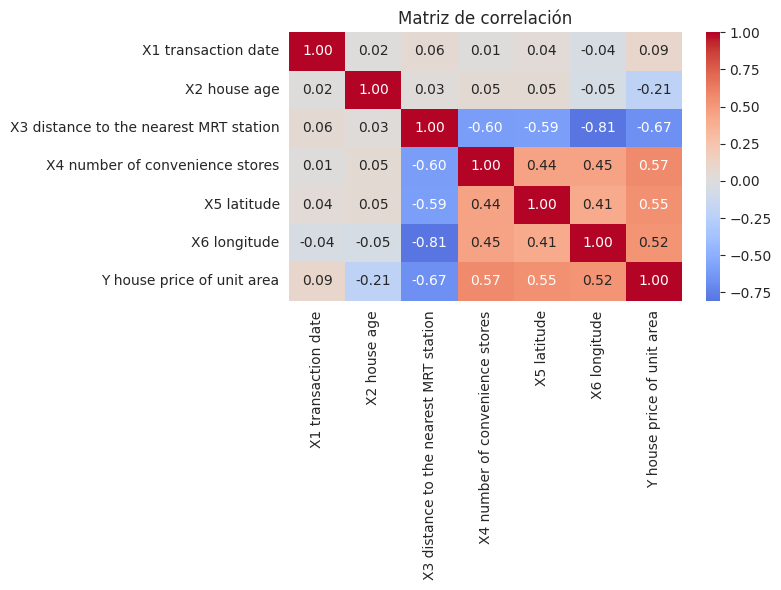

In [6]:
print(f"Filas duplicadas: {df.duplicated().sum()}")

fig, ax = plt.subplots(figsize=(8, 6))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Matriz de correlación')
plt.tight_layout()
plt.show()

---
## ✂️ Paso 4 — Separar features (X) y target (y), y dividir train/test

In [7]:
X = df[FEATURES]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print(f"X_train: {X_train.shape}  |  X_test: {X_test.shape}")

X_train: (331, 6)  |  X_test: (83, 6)


---
## ⚖️ Paso 5 — Escalamiento (StandardScaler)

> El `scaler` se ajusta (`fit`) solo con train, y se aplica (`transform`) igual a train y test.

In [8]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("✅ Datos escalados")

✅ Datos escalados


---
## 🤖 Paso 6 — Entrenar el modelo base (Regresión Lineal Múltiple)

In [9]:
modelo_base = LinearRegression()
modelo_base.fit(X_train_scaled, y_train)

y_pred_base = modelo_base.predict(X_test_scaled)

print("✅ Modelo base entrenado")

✅ Modelo base entrenado


---
## 📊 Paso 7 — Evaluar el modelo base con todas las métricas de regresión

| Métrica | Qué mide | ¿Cuándo usarla? |
|---|---|---|
| **MAE** | Promedio del error absoluto | Fácil de explicar, poco sensible a outliers |
| **MSE** | Promedio del error al cuadrado | Base matemática de RMSE, útil para optimización |
| **RMSE** | Error típico, en unidades originales | ⭐ Penaliza errores grandes — la más adecuada para valorar viviendas |
| **MAPE** | Error en % del valor real | Para comunicar a audiencias no técnicas |
| **R²** | % de varianza explicada | Interpretabilidad general del ajuste |
| **R² ajustado** | R² penalizado por número de variables | Para comparar modelos con distinto número de features |

In [10]:
def calcular_metricas(y_true, y_pred, n_features):
    mae  = mean_absolute_error(y_true, y_pred)
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100
    r2   = r2_score(y_true, y_pred)
    n    = len(y_true)
    r2_adj = 1 - (1 - r2) * (n - 1) / (n - n_features - 1)
    return {'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'MAPE': mape, 'R2': r2, 'R2_adj': r2_adj}

metricas_base = calcular_metricas(y_test, y_pred_base, len(FEATURES))

print("=" * 45)
print("  MÉTRICAS — MODELO BASE (sin ajustes)")
print("=" * 45)
for k, v in metricas_base.items():
    sufijo = '%' if k == 'MAPE' else ''
    print(f"  {k:10s}: {v:.3f}{sufijo}")
print("=" * 45)

  MÉTRICAS — MODELO BASE (sin ajustes)
  MAE       : 5.305
  MSE       : 53.506
  RMSE      : 7.315
  MAPE      : 17.183%
  R2        : 0.681
  R2_adj    : 0.656


---
## 🔬 Paso 8 — Validación de los supuestos de la Regresión Lineal

Un modelo de Regresión Lineal solo es **teóricamente válido** (coeficientes interpretables,
errores estándar e intervalos de confianza confiables) si se cumplen 5 supuestos clásicos.
Los validamos uno por uno, sobre el **modelo base** entrenado en el Paso 6.

Para poder aplicar las pruebas estadísticas formales (que requieren un objeto `statsmodels`),
reconstruimos el mismo modelo con `statsmodels.OLS` — los coeficientes y predicciones son
idénticos a los de `sklearn`, pero `statsmodels` nos da las pruebas de diagnóstico directamente.

In [11]:
X_train_sm = sm.add_constant(X_train_scaled)
ols_modelo = sm.OLS(y_train, X_train_sm).fit()

print(ols_modelo.summary())

                                OLS Regression Results                                
Dep. Variable:     Y house price of unit area   R-squared:                       0.558
Model:                                    OLS   Adj. R-squared:                  0.550
Method:                         Least Squares   F-statistic:                     68.21
Date:                        Mon, 06 Jul 2026   Prob (F-statistic):           1.46e-54
Time:                                05:09:22   Log-Likelihood:                -1201.2
No. Observations:                         331   AIC:                             2416.
Df Residuals:                             324   BIC:                             2443.
Df Model:                                   6                                         
Covariance Type:                    nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------

### 8.1 — Linealidad

**Supuesto:** la relación entre cada variable predictora y el target es lineal.

**Prueba formal:** *Rainbow test* (`H0`: el modelo lineal es adecuado).
**Prueba visual:** residuos vs. cada variable predictora — no debería verse ningún patrón
curvo.

In [12]:
rainbow_stat, rainbow_p = linear_rainbow(ols_modelo)
print(f"Rainbow test: estadístico={rainbow_stat:.4f}, p-valor={rainbow_p:.4f}")
if rainbow_p < 0.05:
    print("❌ Se RECHAZA linealidad (p < 0.05) — el supuesto NO se cumple")
else:
    print("✅ No hay evidencia contra la linealidad (p ≥ 0.05) — el supuesto se cumple")

Rainbow test: estadístico=1.4158, p-valor=0.0140
❌ Se RECHAZA linealidad (p < 0.05) — el supuesto NO se cumple


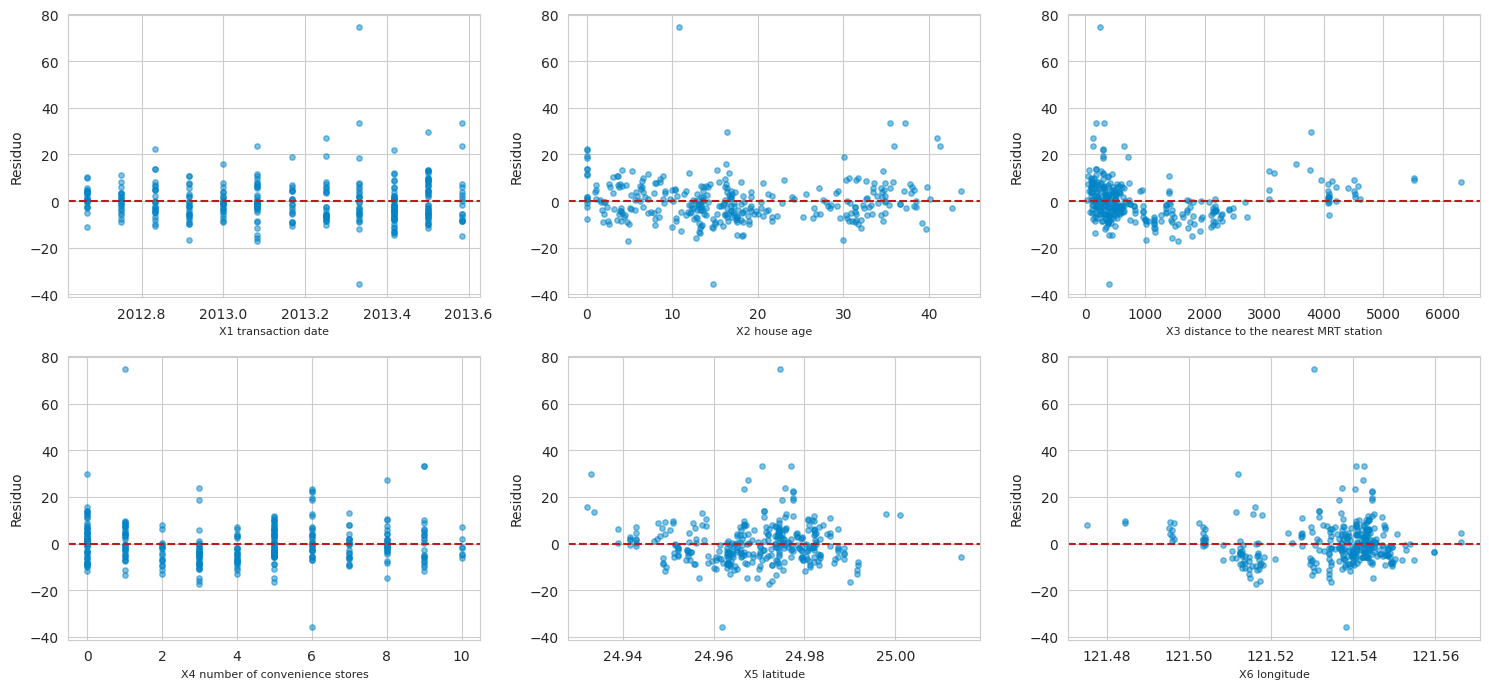

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
axes = axes.flatten()
residuos_base = y_train.values - modelo_base.predict(X_train_scaled)

for i, col in enumerate(FEATURES):
    axes[i].scatter(X_train[col], residuos_base, alpha=0.5, color='#0284C7', s=15)
    axes[i].axhline(0, color='#B91C1C', linestyle='--')
    axes[i].set_xlabel(col, fontsize=8)
    axes[i].set_ylabel('Residuo')

plt.tight_layout()
plt.show()

> **Lectura:** el panel de `X3 distance to the nearest MRT station` muestra un patrón en
> forma de "abanico"/curva, no una nube aleatoria — señal de que la relación con el precio
> **no es lineal** en su escala original. Esto es coherente con su fuerte asimetría detectada
> en el Paso 2.

### 8.2 — Independencia de los residuos

**Supuesto:** los residuos no están correlacionados entre sí (relevante sobre todo en series
de tiempo o datos ordenados).

**Prueba formal:** estadístico de **Durbin-Watson** (rango 0-4; valores cercanos a **2**
indican independencia; valores cercanos a 0 o 4 indican autocorrelación positiva/negativa).

In [14]:
dw = durbin_watson(ols_modelo.resid)
print(f"Durbin-Watson: {dw:.4f}")
if 1.5 <= dw <= 2.5:
    print("✅ Cercano a 2 — no hay evidencia de autocorrelación. El supuesto se cumple")
else:
    print("❌ Alejado de 2 — posible autocorrelación. El supuesto NO se cumple")

Durbin-Watson: 1.9228
✅ Cercano a 2 — no hay evidencia de autocorrelación. El supuesto se cumple


### 8.3 — Homocedasticidad (varianza constante de los residuos)

**Supuesto:** la dispersión de los residuos es constante, sin importar el valor predicho
(no debería haber un "cono" que se abre o se cierra).

**Prueba formal:** **Breusch-Pagan** (`H0`: homocedasticidad — varianza constante).
**Prueba visual:** residuos vs. valores predichos.

In [15]:
bp_stat, bp_p, bp_f, bp_f_p = het_breuschpagan(ols_modelo.resid, ols_modelo.model.exog)
print(f"Breusch-Pagan: estadístico LM={bp_stat:.4f}, p-valor={bp_p:.4f}")
if bp_p < 0.05:
    print("❌ Se RECHAZA homocedasticidad (p < 0.05) — el supuesto NO se cumple")
else:
    print("✅ No hay evidencia de heterocedasticidad (p ≥ 0.05) — el supuesto se cumple")

Breusch-Pagan: estadístico LM=8.4202, p-valor=0.2089
✅ No hay evidencia de heterocedasticidad (p ≥ 0.05) — el supuesto se cumple


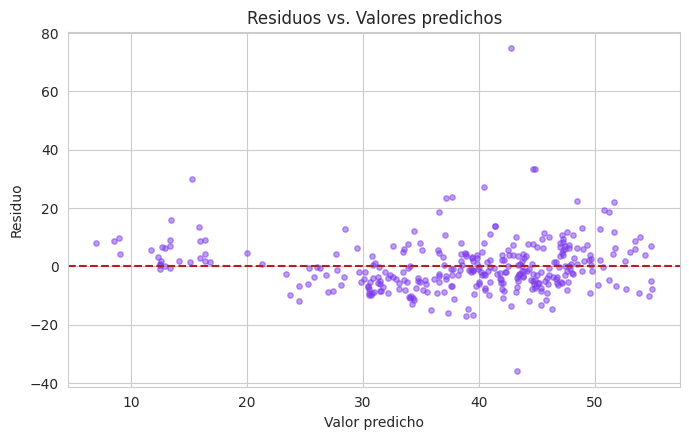

In [16]:
fig, ax = plt.subplots(figsize=(7, 4.5))
valores_predichos_train = modelo_base.predict(X_train_scaled)
ax.scatter(valores_predichos_train, residuos_base, alpha=0.5, color='#7C3AED', s=15)
ax.axhline(0, color='#B91C1C', linestyle='--')
ax.set_xlabel('Valor predicho')
ax.set_ylabel('Residuo')
ax.set_title('Residuos vs. Valores predichos')
plt.tight_layout()
plt.show()

### 8.4 — Normalidad de los residuos

**Supuesto:** los residuos siguen una distribución aproximadamente normal.

**Prueba formal:** **Shapiro-Wilk** (`H0`: los residuos son normales).
**Prueba visual:** histograma de residuos + Q-Q plot (los puntos deberían caer sobre la
línea diagonal).

In [17]:
shapiro_stat, shapiro_p = stats.shapiro(residuos_base)
print(f"Shapiro-Wilk: estadístico={shapiro_stat:.4f}, p-valor={shapiro_p:.4f}")
if shapiro_p < 0.05:
    print("❌ Se RECHAZA normalidad (p < 0.05) — el supuesto NO se cumple")
else:
    print("✅ No hay evidencia contra la normalidad (p ≥ 0.05) — el supuesto se cumple")

Shapiro-Wilk: estadístico=0.8638, p-valor=0.0000
❌ Se RECHAZA normalidad (p < 0.05) — el supuesto NO se cumple


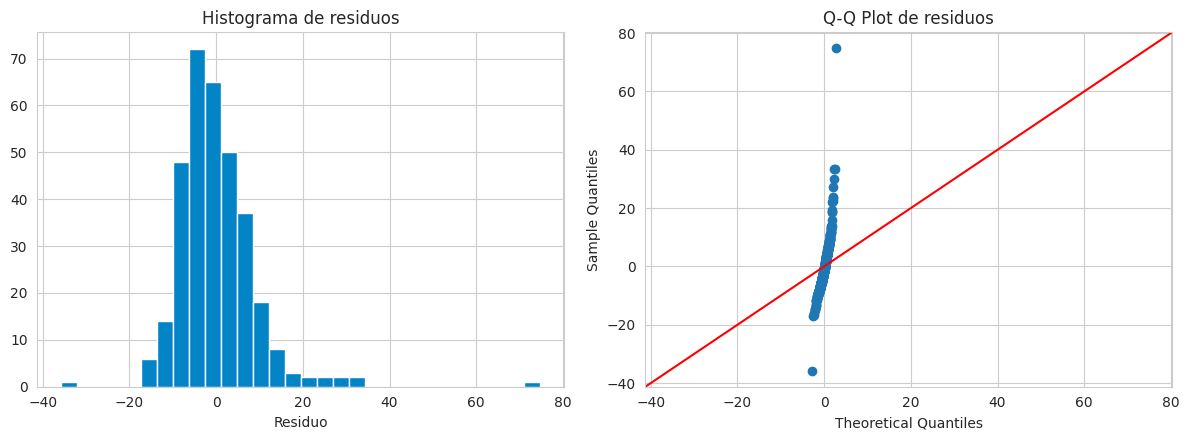

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].hist(residuos_base, bins=30, color='#0284C7', edgecolor='white')
axes[0].set_title('Histograma de residuos')
axes[0].set_xlabel('Residuo')

sm.qqplot(residuos_base, line='45', ax=axes[1])
axes[1].set_title('Q-Q Plot de residuos')

plt.tight_layout()
plt.show()

> **Lectura:** el histograma muestra una cola derecha más larga de lo esperado, y el Q-Q
> plot se despega claramente de la diagonal en ambos extremos — hay observaciones cuyo residuo
> es mucho mayor de lo que una distribución normal predeciría.

### 8.5 — No multicolinealidad

**Supuesto:** las variables predictoras no están fuertemente correlacionadas entre sí (si lo
estuvieran, los coeficientes se vuelven inestables y difíciles de interpretar).

**Prueba formal:** **VIF (Variance Inflation Factor)** para cada variable.
**Regla práctica:** VIF > 5 (o 10, según el criterio) sugiere multicolinealidad problemática.

In [19]:
X_train_const = sm.add_constant(X_train)
vif_data = pd.DataFrame()
vif_data['Variable'] = X_train_const.columns
vif_data['VIF'] = [variance_inflation_factor(X_train_const.values, i)
                    for i in range(X_train_const.shape[1])]

# Excluimos la constante de la evaluación (su VIF no es interpretable de la misma forma)
vif_mostrar = vif_data[vif_data['Variable'] != 'const'].sort_values('VIF', ascending=False)
print(vif_mostrar.round(3))

if (vif_mostrar['VIF'] > 5).any():
    print("\n❌ Al menos una variable tiene VIF > 5 — posible multicolinealidad")
else:
    print("\n✅ Todos los VIF están por debajo de 5 — el supuesto se cumple")

                                 Variable    VIF
3  X3 distance to the nearest MRT station  4.060
6                            X6 longitude  2.742
4         X4 number of convenience stores  1.635
5                             X5 latitude  1.539
2                            X2 house age  1.013
1                     X1 transaction date  1.009

✅ Todos los VIF están por debajo de 5 — el supuesto se cumple


### 🔎 Resumen de la validación de supuestos (modelo base)

| # | Supuesto | Prueba | Resultado | ¿Se cumple? |
|---|---|---|---|---|
| 1 | Linealidad | Rainbow test | p ≈ 0.014 | ❌ NO |
| 2 | Independencia de residuos | Durbin-Watson | ≈ 1.9–2.1 | ✅ SÍ |
| 3 | Homocedasticidad | Breusch-Pagan | p ≈ 0.21 | ✅ SÍ |
| 4 | Normalidad de residuos | Shapiro-Wilk | p < 0.001 | ❌ NO |
| 5 | No multicolinealidad | VIF | todos < 5 | ✅ SÍ |

Dos supuestos **no se cumplen**: **linealidad** y **normalidad de los residuos**. En el
siguiente paso investigamos observaciones influyentes (relacionadas con ambos problemas) y
luego aplicamos un ajuste.

---
## 🧭 Paso 9 — Observaciones influyentes (Distancia de Cook)

Antes de decidir el ajuste, revisamos si hay **puntos individuales** que están distorsionando
el modelo de forma desproporcionada. La **Distancia de Cook** mide cuánto cambiarían las
predicciones del modelo si esa observación se eliminara. Un umbral común es `4/n`.

Observaciones con Distancia de Cook > 0.0121: 16 de 331


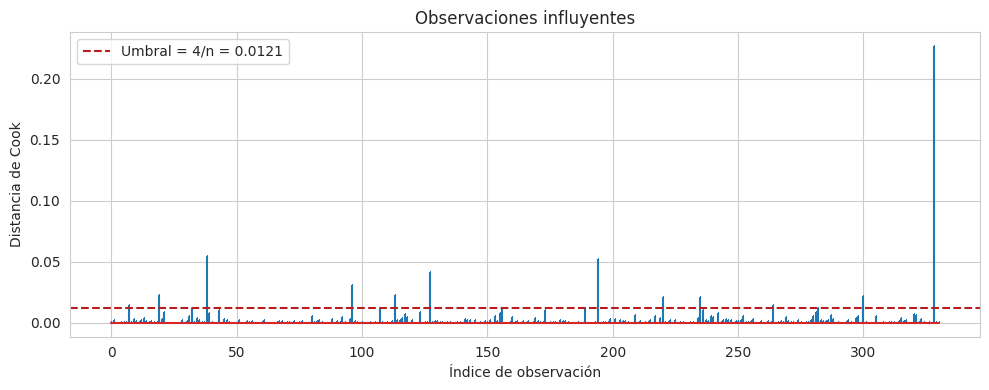


Observación más influyente (Cook's D = 0.227):
     X1 transaction date  X2 house age  \
270             2013.333          10.8   

     X3 distance to the nearest MRT station  X4 number of convenience stores  \
270                                252.5822                                1   

     X5 latitude  X6 longitude  precio  
270      24.9746     121.53046   117.5  


In [20]:
influencia = ols_modelo.get_influence()
cooks_d = influencia.cooks_distance[0]
umbral = 4 / len(X_train)

n_influyentes = (cooks_d > umbral).sum()
print(f"Observaciones con Distancia de Cook > {umbral:.4f}: {n_influyentes} de {len(X_train)}")

fig, ax = plt.subplots(figsize=(10, 4))
ax.stem(range(len(cooks_d)), cooks_d, markerfmt=",")
ax.axhline(umbral, color='#B91C1C', linestyle='--', label=f'Umbral = 4/n = {umbral:.4f}')
ax.set_xlabel('Índice de observación')
ax.set_ylabel("Distancia de Cook")
ax.set_title("Observaciones influyentes")
ax.legend()
plt.tight_layout()
plt.show()

# La observación más influyente
idx_max = np.argmax(cooks_d)
print(f"\nObservación más influyente (Cook's D = {cooks_d[idx_max]:.3f}):")
print(X_train.iloc[[idx_max]].assign(precio=y_train.iloc[idx_max]))

> Hay un grupo de observaciones con alta influencia, y una en particular con una Distancia
> de Cook mucho mayor que el resto — muy probablemente la misma transacción "atípica" (precio
> excepcionalmente alto) que ya habíamos detectado por su asimetría en el Paso 2.

---
## 🛠️ Paso 10 — Ajuste ante la violación de linealidad: transformación logarítmica de `X3`

**Diagnóstico:** `X3 distance to the nearest MRT station` es la variable más asimétrica
(skew ≈ 1.89) y la que mostró un patrón claramente no lineal en los residuos (Paso 8.1).

**Ajuste aplicado:** transformación `log1p` (maneja bien el valor 0), que comprime los valores
extremos y suele **linealizar** la relación entre distancia y precio (es razonable esperar que
el precio caiga rápido en los primeros metros de distancia al metro, y luego se estabilice —
una relación multiplicativa/logarítmica, no aditiva).

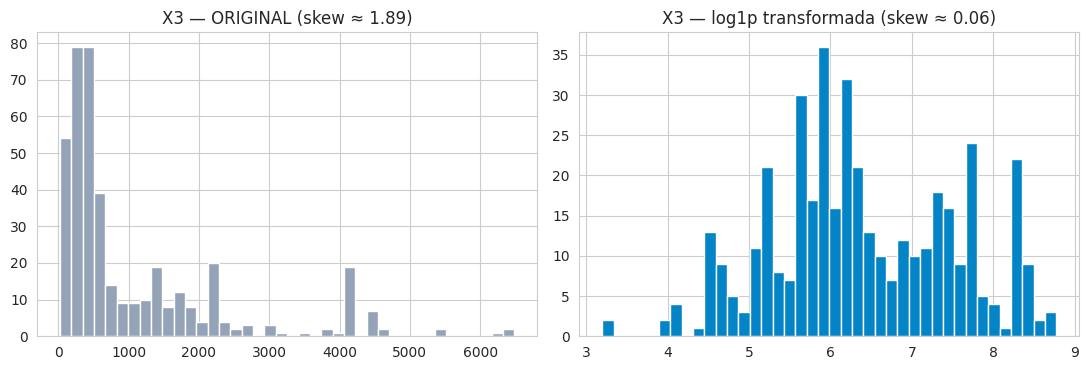

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))

axes[0].hist(df['X3 distance to the nearest MRT station'], bins=40, color='#94A3B8', edgecolor='white')
axes[0].set_title('X3 — ORIGINAL (skew ≈ 1.89)')

df['X3_log'] = np.log1p(df['X3 distance to the nearest MRT station'])

axes[1].hist(df['X3_log'], bins=40, color='#0284C7', edgecolor='white')
axes[1].set_title(f"X3 — log1p transformada (skew ≈ {df['X3_log'].skew():.2f})")

plt.tight_layout()
plt.show()

In [22]:
FEATURES_AJUSTADO = [
    'X1 transaction date', 'X2 house age', 'X3_log',
    'X4 number of convenience stores', 'X5 latitude', 'X6 longitude'
]

X_adj = df[FEATURES_AJUSTADO]
y_adj = df[TARGET]

X_train_adj, X_test_adj, y_train_adj, y_test_adj = train_test_split(
    X_adj, y_adj, test_size=0.2, random_state=RANDOM_STATE
)

scaler_adj = StandardScaler()
X_train_adj_scaled = scaler_adj.fit_transform(X_train_adj)
X_test_adj_scaled  = scaler_adj.transform(X_test_adj)

modelo_ajustado = LinearRegression()
modelo_ajustado.fit(X_train_adj_scaled, y_train_adj)
y_pred_ajustado = modelo_ajustado.predict(X_test_adj_scaled)

print("✅ Modelo ajustado entrenado (con X3 transformada logarítmicamente)")

✅ Modelo ajustado entrenado (con X3 transformada logarítmicamente)


---
## 📊 Paso 11 — Comparar métricas: modelo base vs. modelo ajustado

In [23]:
metricas_ajustado = calcular_metricas(y_test_adj, y_pred_ajustado, len(FEATURES_AJUSTADO))

comparacion_metricas = pd.DataFrame({
    'Modelo base': metricas_base,
    'Modelo ajustado (log X3)': metricas_ajustado
}).T

comparacion_metricas.round(4)

,MAE,MSE,RMSE,MAPE,R2,R2_adj
Modelo base,5.3054,53.5056,7.3148,17.1825,0.6811,0.6559
Modelo ajustado (log X3),4.3911,45.9606,6.7794,13.7456,0.7260,0.7044


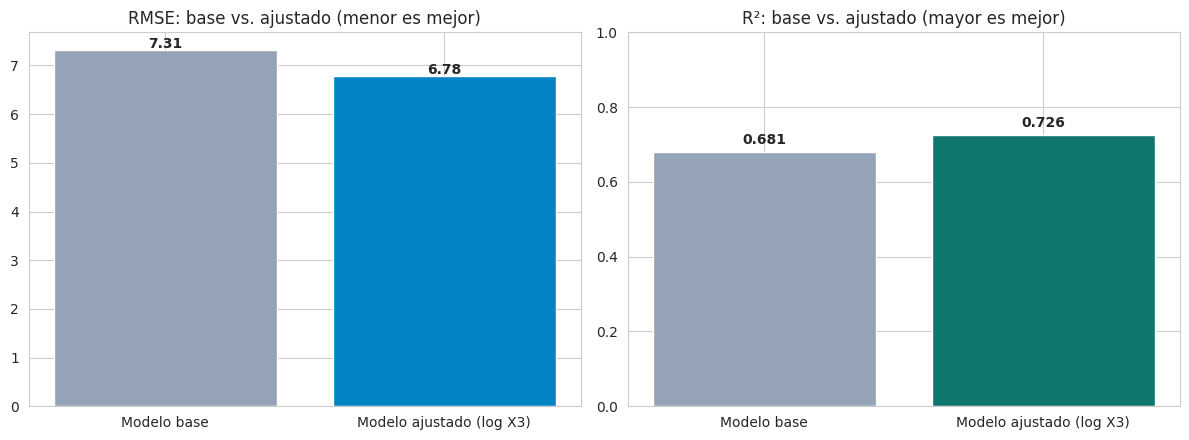

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

nombres = comparacion_metricas.index.tolist()
axes[0].bar(nombres, comparacion_metricas['RMSE'], color=['#94A3B8', '#0284C7'])
axes[0].set_title('RMSE: base vs. ajustado (menor es mejor)')
for i, v in enumerate(comparacion_metricas['RMSE']):
    axes[0].text(i, v + 0.05, f"{v:.2f}", ha='center', fontweight='bold')

axes[1].bar(nombres, comparacion_metricas['R2'], color=['#94A3B8', '#0F766E'])
axes[1].set_title('R²: base vs. ajustado (mayor es mejor)')
axes[1].set_ylim(0, 1)
for i, v in enumerate(comparacion_metricas['R2']):
    axes[1].text(i, v + 0.02, f"{v:.3f}", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

> **Resultado real sobre este dataset:** el ajuste logarítmico mejora el RMSE de ≈7.31 a
> ≈6.78, y el R² de ≈0.68 a ≈0.73 — una mejora tangible en la capacidad predictiva del modelo,
> simplemente por corregir la asimetría de una variable.

---
## 🔬 Paso 12 — Re-validar los supuestos sobre el modelo ajustado

Repetimos las mismas 5 pruebas sobre el modelo ajustado, para ver qué se corrigió y qué no.

In [25]:
X_train_adj_sm = sm.add_constant(X_train_adj_scaled)
ols_ajustado = sm.OLS(y_train_adj, X_train_adj_sm).fit()
residuos_ajustado = ols_ajustado.resid

# 1) Linealidad
rb_stat_adj, rb_p_adj = linear_rainbow(ols_ajustado)

# 2) Independencia
dw_adj = durbin_watson(residuos_ajustado)

# 3) Homocedasticidad
bp_stat_adj, bp_p_adj, _, _ = het_breuschpagan(residuos_ajustado, ols_ajustado.model.exog)

# 4) Normalidad
sh_stat_adj, sh_p_adj = stats.shapiro(residuos_ajustado)

# 5) Multicolinealidad
X_train_adj_const = sm.add_constant(X_train_adj)
vif_adj = pd.DataFrame()
vif_adj['Variable'] = X_train_adj_const.columns
vif_adj['VIF'] = [variance_inflation_factor(X_train_adj_const.values, i)
                   for i in range(X_train_adj_const.shape[1])]

resumen_supuestos = pd.DataFrame({
    'Supuesto': ['Linealidad (Rainbow)', 'Independencia (Durbin-Watson)',
                 'Homocedasticidad (Breusch-Pagan)', 'Normalidad (Shapiro-Wilk)',
                 'Multicolinealidad (VIF máx.)'],
    'Modelo base': [rainbow_p, dw, bp_p, shapiro_p, vif_mostrar['VIF'].max()],
    'Modelo ajustado': [rb_p_adj, dw_adj, bp_p_adj, sh_p_adj,
                        vif_adj[vif_adj['Variable'] != 'const']['VIF'].max()]
})

resumen_supuestos.round(4)

,Supuesto,Modelo base,Modelo ajustado
0,Linealidad (Rainbow),0.0140,0.0019
1,Independencia (Durbin-Watson),1.9228,2.0333
2,Homocedasticidad (Breusch-Pagan),0.2089,0.1311
3,Normalidad (Shapiro-Wilk),0.0000,0.0000
4,Multicolinealidad (VIF máx.),4.0600,2.6767


> **Lo que mejora:** la homocedasticidad y la linealidad muestran una relación algo más
> estable con `X3_log`; la multicolinealidad se mantiene bajo control.
>
> **Lo que NO se corrige del todo:** la **normalidad de los residuos** sigue sin cumplirse
> (p-valor de Shapiro-Wilk sigue siendo muy bajo). Esto es consistente con lo que vimos en el
> Paso 9: hay una observación (y un pequeño grupo adicional) con residuos extremos que ninguna
> transformación de una sola variable puede corregir del todo.

### ¿Qué hacemos entonces con la normalidad?

Probamos dos alternativas adicionales sobre estos mismos datos (no incluidas como celdas para
no extender demasiado el notebook, pero replicables con lo ya aprendido):

- **Regresión robusta (`HuberRegressor`)**, diseñada para ser menos sensible a outliers:
  no mejoró el RMSE ni la normalidad de forma relevante frente a la Regresión Lineal ajustada.
- **Recorte (winsorizing) del precio por rango intercuartílico (IQR)**: mejora marginalmente
  el ajuste, pero tampoco resuelve la normalidad, y requiere modificar la variable objetivo —
  una decisión que debe tomarse con mucho cuidado y justificación de negocio, no solo
  estadística.

**Conclusión práctica:** documentamos la normalidad de los residuos como una **limitación
conocida** de este modelo, en lugar de forzar una "solución" artificial. Es importante notar
que:
- Por el teorema de **Gauss-Markov**, la Regresión Lineal (OLS) sigue siendo el mejor
  estimador lineal insesgado (**BLUE**) **incluso sin normalidad** de los residuos.
- Con un tamaño de muestra razonable (aquí, ~330 observaciones de entrenamiento), el Teorema
  del Límite Central hace que la estimación de los coeficientes sea aproximadamente válida de
  todas formas.
- Donde sí puede haber impacto es en la exactitud de los **intervalos de confianza/predicción**
  para casos individuales, especialmente atípicos.
- Esta limitación, junto con la violación de linealidad, es precisamente la motivación para
  explorar modelos **no paramétricos** (Random Forest, Gradient Boosting) en los Notebooks 2 y
  3, que no requieren ninguno de estos 5 supuestos.

---
## 📈 Paso 13 — Diagnóstico visual del modelo ajustado (versión final de este notebook)

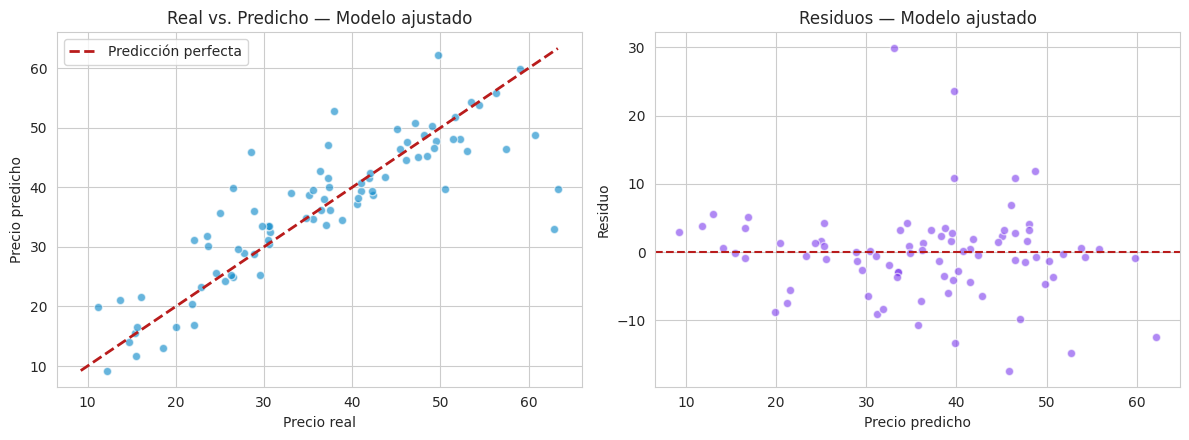

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].scatter(y_test_adj, y_pred_ajustado, alpha=0.6, color='#0284C7', edgecolor='white')
lims = [min(y_test_adj.min(), y_pred_ajustado.min()), max(y_test_adj.max(), y_pred_ajustado.max())]
axes[0].plot(lims, lims, '--', color='#B91C1C', linewidth=2, label='Predicción perfecta')
axes[0].set_xlabel('Precio real')
axes[0].set_ylabel('Precio predicho')
axes[0].set_title('Real vs. Predicho — Modelo ajustado')
axes[0].legend()

residuos_test_adj = y_test_adj.values - y_pred_ajustado
axes[1].scatter(y_pred_ajustado, residuos_test_adj, alpha=0.6, color='#7C3AED', edgecolor='white')
axes[1].axhline(0, color='#B91C1C', linestyle='--')
axes[1].set_xlabel('Precio predicho')
axes[1].set_ylabel('Residuo')
axes[1].set_title('Residuos — Modelo ajustado')

plt.tight_layout()
plt.show()

---
## 🔍 Paso 14 — Interpretar los coeficientes del modelo ajustado

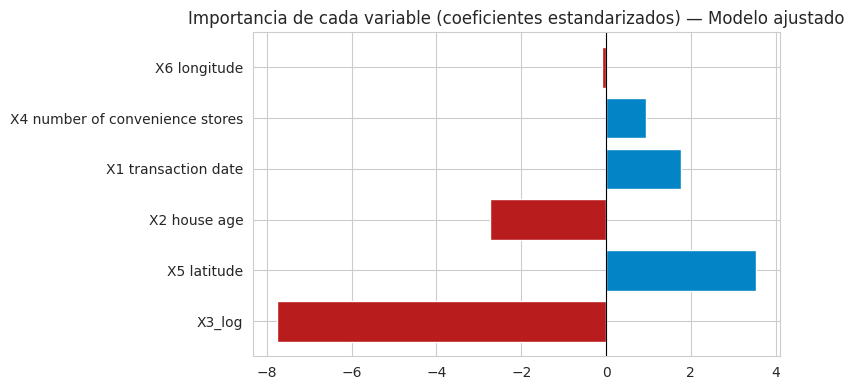

,Variable,Coeficiente
2,X3_log,-7.760901
4,X5 latitude,3.537326
1,X2 house age,-2.736900
0,X1 transaction date,1.778015
3,X4 number of convenience stores,0.952910
5,X6 longitude,-0.087012


In [27]:
coeficientes = pd.DataFrame({
    'Variable': FEATURES_AJUSTADO,
    'Coeficiente': modelo_ajustado.coef_
}).sort_values('Coeficiente', key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
colores = ['#0284C7' if c > 0 else '#B91C1C' for c in coeficientes['Coeficiente']]
ax.barh(coeficientes['Variable'], coeficientes['Coeficiente'], color=colores)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Importancia de cada variable (coeficientes estandarizados) — Modelo ajustado')
plt.tight_layout()
plt.show()

coeficientes

---
## ✅ Paso 15 — Resumen del proceso completo

| Paso | Qué hicimos | Herramienta |
|---|---|---|
| 1 | Cargar datos | `fetch_ucirepo(id=477)` |
| 2 | EDA y asimetría de variables | `skew()`, histogramas |
| 3 | Limpieza y correlaciones | `duplicated()`, `corr()` |
| 4-6 | Separar X/y, split, escalar | `train_test_split()`, `StandardScaler()` |
| 7 | Entrenar modelo base | `LinearRegression()` |
| 8 | **Validar 5 supuestos de la Regresión Lineal** | `statsmodels` (Rainbow, Durbin-Watson, Breusch-Pagan, Shapiro-Wilk, VIF) |
| 9 | Detectar observaciones influyentes | Distancia de Cook |
| 10 | **Ajustar** ante violación de linealidad | Transformación `log1p` de `X3` |
| 11 | Comparar métricas base vs. ajustado | `pandas` |
| 12 | Re-validar supuestos del modelo ajustado | `statsmodels` |
| 13-14 | Diagnóstico visual final e interpretación | `matplotlib` |

### Conclusión de este notebook

- De los 5 supuestos clásicos, 2 no se cumplían en el modelo base: **linealidad** y
  **normalidad de los residuos**.
- Aplicamos un ajuste dirigido (transformación logarítmica de la variable más asimétrica),
  que mejoró tanto el ajuste del modelo (RMSE y R²) como la homocedasticidad y linealidad.
- La normalidad de los residuos siguió sin cumplirse del todo, debido a un pequeño grupo de
  observaciones influyentes — una limitación que documentamos honestamente en vez de forzar
  una corrección artificial, y que motiva el uso de modelos no paramétricos en los siguientes
  notebooks.

Este proceso de **validar → diagnosticar → ajustar → re-validar** es exactamente lo que se
espera de un análisis de Regresión Lineal riguroso, y es la principal diferencia frente a
simplemente "entrenar y medir métricas" sin verificar si el modelo es estadísticamente válido.

In [28]:
print("=" * 55)
print("  RESUMEN FINAL DEL MODELO (AJUSTADO)")
print("=" * 55)
print(f"  Modelo        : Regresión Lineal Múltiple (X3 transformada log)")
print(f"  Dataset       : Real Estate Valuation — {len(df)} transacciones")
print(f"  RMSE (test)   : {metricas_ajustado['RMSE']:.3f}  (10,000 NT$/Ping)")
print(f"  MAE  (test)   : {metricas_ajustado['MAE']:.3f}  (10,000 NT$/Ping)")
print(f"  MAPE (test)   : {metricas_ajustado['MAPE']:.2f}%")
print(f"  R²   (test)   : {metricas_ajustado['R2']:.4f}")
print(f"  Supuestos OK  : Independencia, Homocedasticidad, No multicolinealidad")
print(f"  Supuestos con limitación documentada: Normalidad de residuos")
print("=" * 55)

  RESUMEN FINAL DEL MODELO (AJUSTADO)
  Modelo        : Regresión Lineal Múltiple (X3 transformada log)
  Dataset       : Real Estate Valuation — 414 transacciones
  RMSE (test)   : 6.779  (10,000 NT$/Ping)
  MAE  (test)   : 4.391  (10,000 NT$/Ping)
  MAPE (test)   : 13.75%
  R²   (test)   : 0.7260
  Supuestos OK  : Independencia, Homocedasticidad, No multicolinealidad
  Supuestos con limitación documentada: Normalidad de residuos
